<a href="https://colab.research.google.com/github/FhmiKh19/Probabilitas-Statistika/blob/main/analisis_sinyal_seluler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Pustaka dan parameter

In [3]:
import os, json, hashlib, sys, math, warnings
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

FILE  = "oscn.xlsx"
ORDER = ["Home", "Open", "Suburban", "Urban"]
WARNA = {"Home": "#2a9d8f", "Open": "#e9c46a", "Suburban": "#f4a261", "Urban": "#e76f51"}
os.makedirs("figures", exist_ok=True)
HASIL = {"versi": {"python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
                   "matplotlib": matplotlib.__version__}}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "figure.dpi": 130})

## 2. Memuat data dan pemeriksaan awal

In [4]:
df = pd.read_excel(FILE).rename(columns={"Signal Strength (dBm)": "sinyal", "Distance to Tower (km)": "jarak",
                                         "Attenuation": "atenuasi", "Environment": "env"})
HASIL["sha256"] = hashlib.sha256(open(FILE, "rb").read()).hexdigest()
HASIL["n"], HASIL["kolom"] = int(df.shape[0]), int(df.shape[1])
print("Baris, kolom:", df.shape); print("SHA-256:", HASIL["sha256"]); print(df.dtypes)
df.head()

Baris, kolom: (463, 11)
SHA-256: e5f82da7032ffac3fc89cc160c01a3b1d3a8362b7f9e3b02651fa98112af7384
Timestamp             object
sinyal               float64
SNR                  float64
Call Duration (s)    float64
env                   object
atenuasi             float64
jarak                float64
Tower ID               int64
User ID                int64
Call Type             object
Incoming/Outgoing     object
dtype: object


,Timestamp,sinyal,SNR,Call Duration (s),env,atenuasi,jarak,Tower ID,User ID,Call Type,Incoming/Outgoing
0,2022-01-03 17:46:13,-84.12,25.94,1713.8,Urban,14.69,2.24,5,25,Data,Incoming
1,2022-01-04 17:29:31,-87.81,15.94,345.4,Home,6.21,5.00,3,22,Voice,Incoming
2,2022-01-05 17:14:01,-116.58,14.71,259.3,Open,4.49,8.71,2,5,Voice,Incoming
3,2022-01-06 16:02:29,-82.96,21.73,358.0,Home,7.62,7.43,5,33,Data,Outgoing
4,2022-01-07 22:19:17,-85.01,26.06,398.0,Urban,10.66,0.61,5,8,Voice,Outgoing


In [5]:
# Kelengkapan, duplikat, Timestamp, nilai di luar 1,5 x IQR
HASIL["nilai_kosong"] = int(df.isna().sum().sum())
HASIL["duplikat"] = int(df.duplicated().sum())
ts = pd.to_datetime(df["Timestamp"].astype(str), errors="coerce")
HASIL["ts_tidak_valid"] = [str(v) for v in df.loc[ts.isna(), "Timestamp"]]
HASIL["ts_baris_excel"] = [int(i) + 2 for i in df.index[ts.isna()]]
print("Nilai kosong:", HASIL["nilai_kosong"], "| duplikat:", HASIL["duplikat"], "| Timestamp tidak valid:", HASIL["ts_tidak_valid"])
print(df["env"].value_counts().to_dict())
def n_outlier(x):
    q1, q3 = x.quantile([.25, .75]); i = q3 - q1
    return int(((x < q1 - 1.5*i) | (x > q3 + 1.5*i)).sum())
out = df.groupby("env")[["sinyal", "jarak", "atenuasi"]].agg(n_outlier).loc[ORDER]
HASIL["outlier_total"] = int(out.values.sum()); out

Nilai kosong: 0 | duplikat: 0 | Timestamp tidak valid: ['2022-02-29 12:08:52']
{'Open': 132, 'Urban': 111, 'Home': 110, 'Suburban': 110}


,sinyal,jarak,atenuasi
env,,,
Home,0,0,0
Open,0,0,0
Suburban,0,0,0
Urban,0,0,0


## 3. Statistika deskriptif per tipe lingkungan

In [6]:
def ringkas(s):
    return {"n": s.count(), "rata2": s.mean(), "median": s.median(), "sd": s.std(), "min": s.min(), "maks": s.max(),
            "Q1": s.quantile(.25), "Q3": s.quantile(.75), "IQR": s.quantile(.75) - s.quantile(.25),
            "skew": s.skew(), "kurt": s.kurt()}      # skew dan kurt: koefisien kemiringan dan keruncingan (excess)
def desc(col):
    t = pd.DataFrame({e: ringkas(df.loc[df.env == e, col]) for e in ORDER}).T
    t.loc["Semua"] = ringkas(df[col])
    return t.astype(float).round(2)
for col in ["sinyal", "jarak", "atenuasi"]:
    HASIL["desc_" + col] = desc(col).to_dict(orient="index"); print("==", col); display(desc(col))

== sinyal


,n,rata2,median,sd,min,maks,Q1,Q3,IQR,skew,kurt
Home,110.0,-79.52,-79.31,11.40,-99.81,-60.44,-88.30,-71.42,16.88,-0.09,-1.05
Open,132.0,-84.03,-82.16,18.83,-118.68,-50.12,-98.89,-68.52,30.37,-0.08,-1.04
Suburban,110.0,-85.80,-87.00,11.20,-104.92,-65.05,-94.94,-76.49,18.45,0.11,-1.16
Urban,111.0,-90.60,-89.97,11.21,-109.18,-70.47,-100.83,-80.96,19.87,-0.04,-1.25
Semua,463.0,-84.96,-84.23,14.35,-118.68,-50.12,-95.94,-74.43,21.50,0.01,-0.60


== jarak


,n,rata2,median,sd,min,maks,Q1,Q3,IQR,skew,kurt
Home,110.0,4.74,4.82,2.80,0.04,9.98,2.48,7.25,4.77,0.04,-1.10
Open,132.0,4.65,4.50,3.07,0.03,9.98,2.02,7.50,5.48,0.13,-1.33
Suburban,110.0,5.56,5.62,2.74,0.07,9.93,3.32,8.08,4.76,-0.21,-1.11
Urban,111.0,5.40,5.90,3.10,0.12,9.92,2.42,8.15,5.74,-0.19,-1.35
Semua,463.0,5.06,5.18,2.96,0.03,9.98,2.51,7.71,5.20,-0.05,-1.26


== atenuasi


,n,rata2,median,sd,min,maks,Q1,Q3,IQR,skew,kurt
Home,110.0,5.20,5.64,2.91,0.07,9.98,2.56,7.61,5.04,-0.13,-1.21
Open,132.0,2.55,2.50,1.50,0.04,4.99,1.36,3.85,2.50,-0.03,-1.29
Suburban,110.0,4.89,4.68,1.73,2.00,7.99,3.42,6.22,2.80,0.16,-1.11
Urban,111.0,9.75,9.77,2.89,5.14,14.94,7.11,12.18,5.08,0.09,-1.16
Semua,463.0,5.46,4.76,3.50,0.04,14.94,2.82,7.58,4.76,0.68,-0.11


## 4. Tabel distribusi frekuensi kekuatan sinyal (aturan Sturges)

In [7]:
n = len(df)
k = math.ceil(1 + 3.322 * math.log10(n))                       # banyak kelas
rentang = df["sinyal"].max() - df["sinyal"].min()
lebar = math.ceil(rentang / k * 10) / 10                      # lebar kelas, dibulatkan ke atas 1 desimal
bawah = math.floor(df["sinyal"].min() * 10) / 10
batas = [round(bawah + i * lebar, 1) for i in range(k + 1)]
kelas = pd.cut(df["sinyal"], bins=batas, right=False)
fr = kelas.value_counts().sort_index()
tab = pd.DataFrame({"bawah": batas[:-1], "atas": batas[1:], "frekuensi": fr.values})
tab["relatif_%"] = tab["frekuensi"] / n * 100
tab["kumulatif_%"] = tab["relatif_%"].cumsum()
HASIL["frekuensi"] = {"k": k, "rentang": float(rentang), "lebar": lebar, "tabel": tab.round(2).to_dict(orient="records")}
print("k =", k, "| rentang =", round(rentang, 2), "| lebar kelas =", lebar); tab.round(2)

k = 10 | rentang = 68.56 | lebar kelas = 6.9


,bawah,atas,frekuensi,relatif_%,kumulatif_%
0,-118.7,-111.8,12,2.59,2.59
1,-111.8,-104.9,29,6.26,8.86
2,-104.9,-98.0,57,12.31,21.17
3,-98.0,-91.1,70,15.12,36.29
4,-91.1,-84.2,65,14.04,50.32
5,-84.2,-77.3,74,15.98,66.31
6,-77.3,-70.4,79,17.06,83.37
7,-70.4,-63.5,49,10.58,93.95
8,-63.5,-56.6,20,4.32,98.27
9,-56.6,-49.7,8,1.73,100.00


## 5. Proporsi sinyal di kuartil terbawah

In [8]:
# Q1 seluruh data menjadi batas: 25% panggilan dengan sinyal terlemah berada di bawah atau sama dengan nilai ini
Q1_SEMUA = df["sinyal"].quantile(.25)
bawah25 = (df["sinyal"] <= Q1_SEMUA).groupby(df["env"]).mean().loc[ORDER] * 100
HASIL["q1_semua"] = float(Q1_SEMUA)
HASIL["bawah25"] = {e: float(bawah25[e]) for e in ORDER}
print("Q1 seluruh data:", round(Q1_SEMUA, 2), "dBm"); print(bawah25.round(1).to_dict())

Q1 seluruh data: -95.94 dBm
{'Home': 10.0, 'Open': 30.3, 'Suburban': 22.7, 'Urban': 36.0}


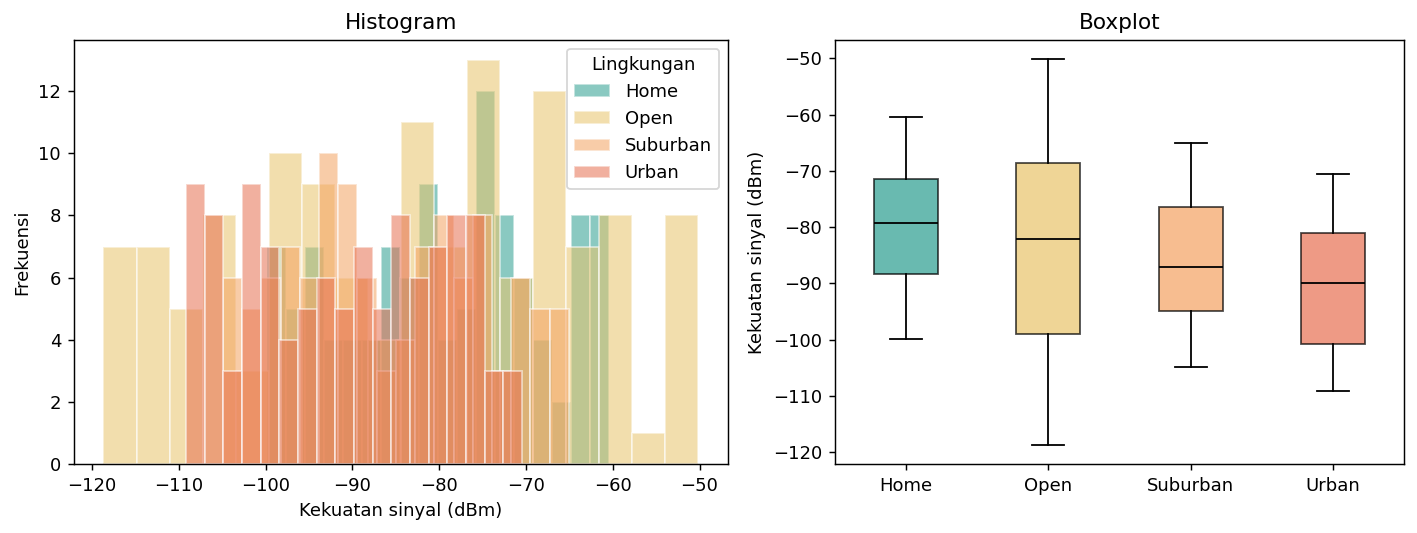

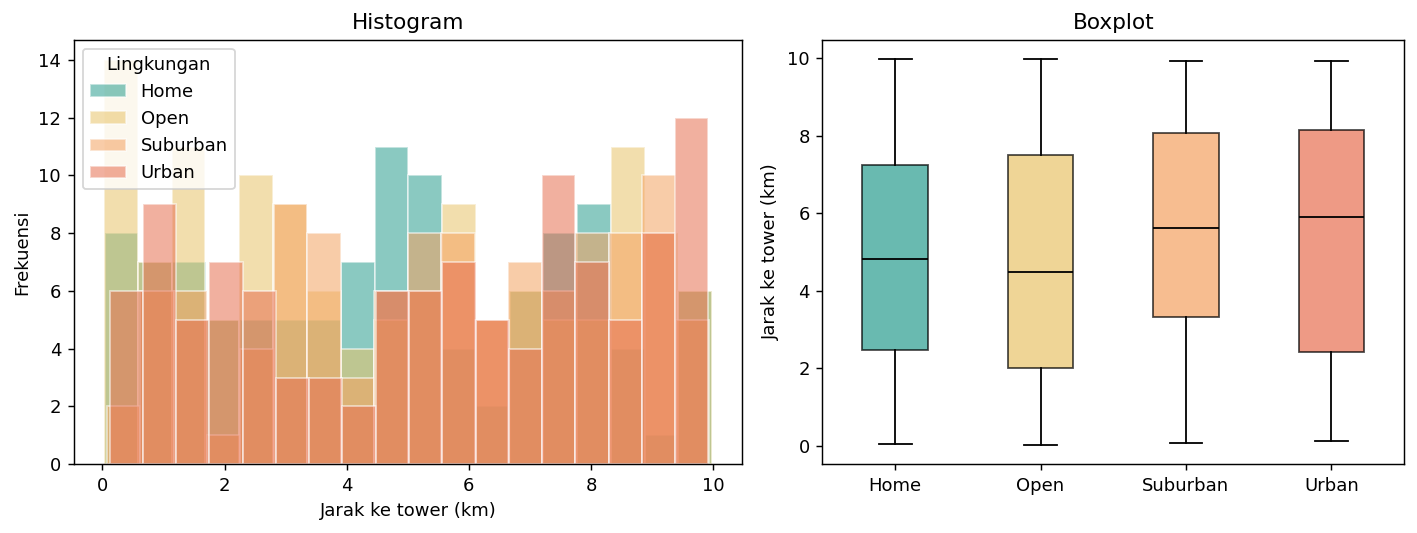

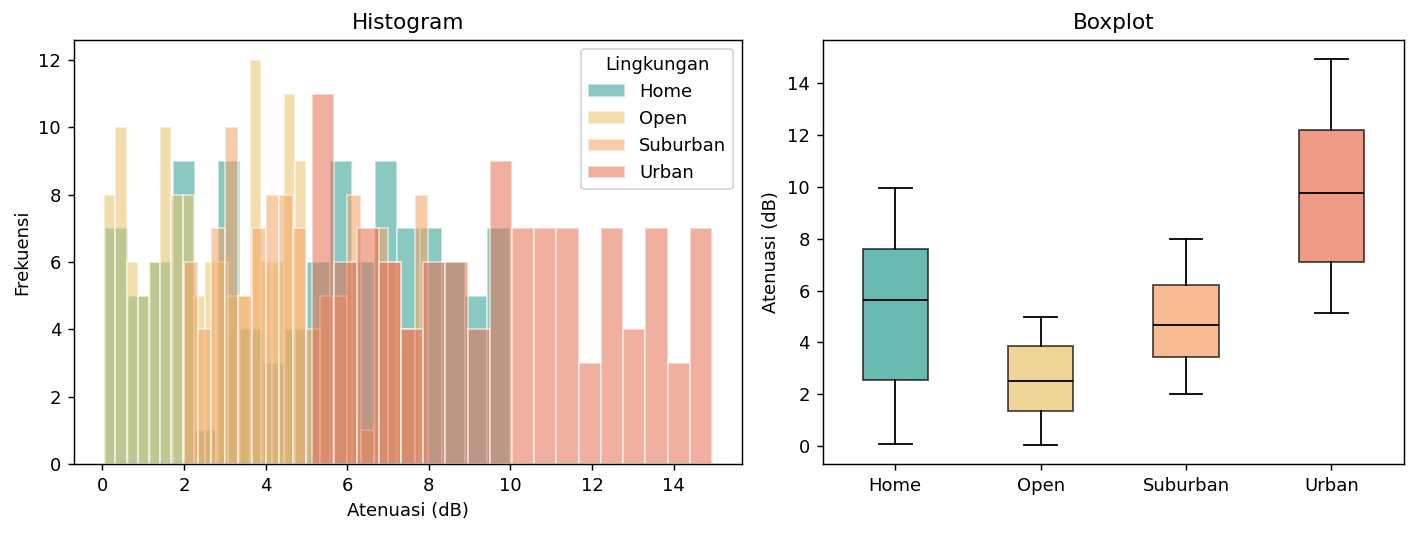

In [9]:
# Gambar 4.1 - 4.3: histogram dan boxplot per tipe lingkungan
def gambar_sebaran(col, judul, satuan, nama):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
    for e in ORDER:
        ax[0].hist(df.loc[df.env == e, col], bins=18, alpha=.55, color=WARNA[e], label=e, edgecolor="white")
    ax[0].set_xlabel(f"{judul} ({satuan})"); ax[0].set_ylabel("Frekuensi"); ax[0].legend(title="Lingkungan"); ax[0].set_title("Histogram")
    bp = ax[1].boxplot([df.loc[df.env == e, col] for e in ORDER], labels=ORDER, patch_artist=True, medianprops=dict(color="black"))
    for p_, e in zip(bp["boxes"], ORDER): p_.set_facecolor(WARNA[e]); p_.set_alpha(.7)
    ax[1].set_ylabel(f"{judul} ({satuan})"); ax[1].set_title("Boxplot")
    plt.tight_layout(); plt.savefig(f"figures/{nama}.png", dpi=200); plt.show()
gambar_sebaran("sinyal", "Kekuatan sinyal", "dBm", "gambar_4_1_sinyal")
gambar_sebaran("jarak", "Jarak ke tower", "km", "gambar_4_2_jarak")
gambar_sebaran("atenuasi", "Atenuasi", "dB", "gambar_4_3_atenuasi")

## 6. Kekuatan sinyal menurut kelompok jarak dan kelompok atenuasi (tertil)

In [10]:
# Tiga kelompok berukuran sama (tertil) agar batas kelompok ditentukan data, bukan pilihan peneliti
df["jarak_kel"] = pd.qcut(df["jarak"], 3, labels=["Dekat", "Sedang", "Jauh"])
df["atenuasi_kel"] = pd.qcut(df["atenuasi"], 3, labels=["Rendah", "Sedang", "Tinggi"])
for kolom, nama in [("jarak_kel", "jarak"), ("atenuasi_kel", "atenuasi")]:
    g = df.groupby(kolom, observed=True)
    tab = pd.DataFrame({"n": g["sinyal"].count(), "batas_bawah": g[nama].min(), "batas_atas": g[nama].max(),
                        "median_x": g[nama].median(), "rata2": g["sinyal"].mean(), "median": g["sinyal"].median(),
                        "sd": g["sinyal"].std(), "bawah25_%": g["sinyal"].apply(lambda s: (s <= Q1_SEMUA).mean() * 100)}).round(2)
    HASIL["kel_" + nama] = tab.to_dict(orient="index"); print("==", kolom); display(tab)
komp = (pd.crosstab(df["atenuasi_kel"], df["env"], normalize="index") * 100).round(1)[ORDER]
HASIL["komposisi_atenuasi"] = komp.to_dict(orient="index"); komp

== jarak_kel


,n,batas_bawah,batas_atas,median_x,rata2,median,sd,bawah25_%
jarak_kel,,,,,,,,
Dekat,154,0.03,3.26,1.50,-83.56,-82.31,14.58,20.78
Sedang,154,3.31,6.89,5.18,-85.07,-84.51,14.44,28.57
Jauh,155,6.95,9.98,8.42,-86.23,-87.25,13.99,25.81


== atenuasi_kel


,n,batas_bawah,batas_atas,median_x,rata2,median,sd,bawah25_%
atenuasi_kel,,,,,,,,
Rendah,154,0.04,3.52,1.96,-83.67,-82.16,15.87,25.32
Sedang,154,3.57,6.66,4.76,-84.69,-84.26,14.41,24.03
Tinggi,155,6.67,14.94,8.82,-86.50,-86.19,12.53,25.81


env,Home,Open,Suburban,Urban
atenuasi_kel,,,,
Rendah,24.7,55.8,19.5,0.0
Sedang,19.5,29.9,36.4,14.3
Tinggi,27.1,0.0,15.5,57.4


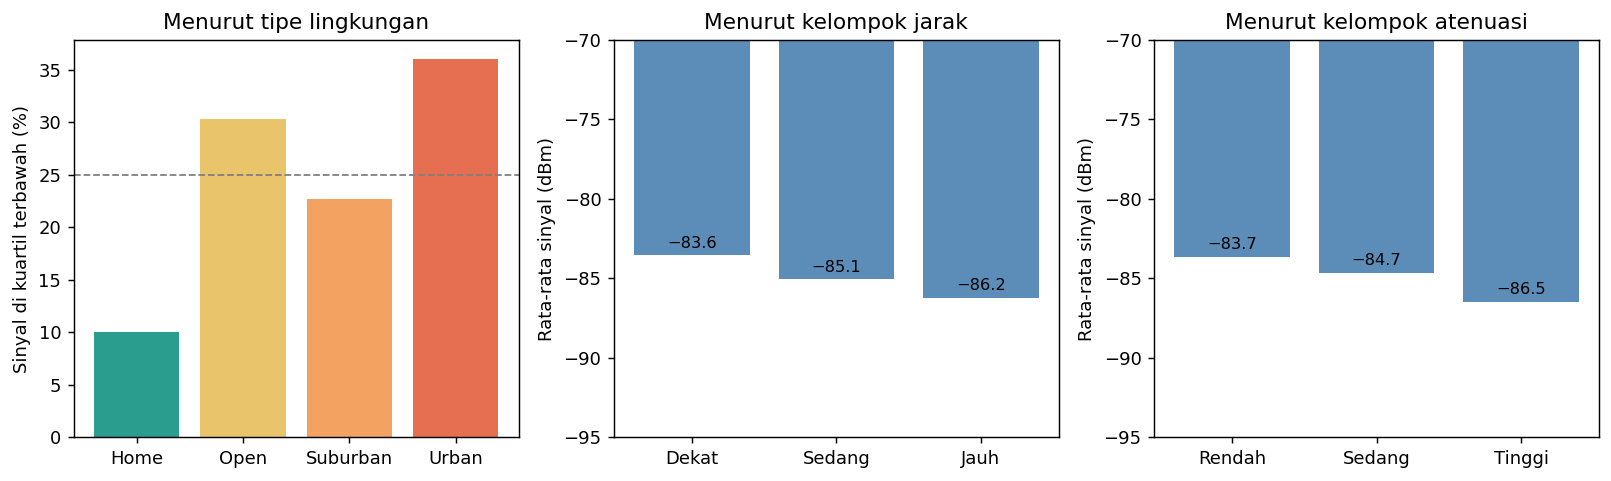

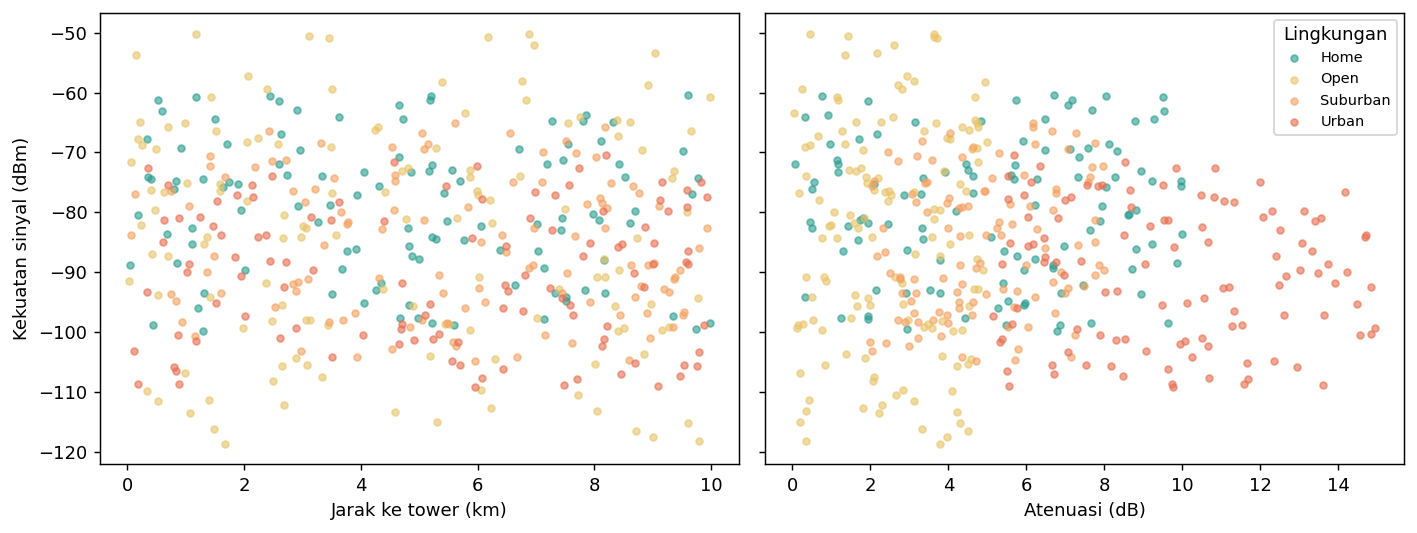

In [11]:
# Gambar 4.4: proporsi kuartil terbawah dan rata-rata sinyal per kelompok; Gambar 4.5: diagram pencar
fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.8))
axs[0].bar(ORDER, [HASIL["bawah25"][e] for e in ORDER], color=[WARNA[e] for e in ORDER])
axs[0].axhline(25, color="gray", ls="--", lw=1); axs[0].set_ylabel("Sinyal di kuartil terbawah (%)"); axs[0].set_title("Menurut tipe lingkungan")
for a, key, lab, ttl in [(axs[1], "kel_jarak", ["Dekat", "Sedang", "Jauh"], "Menurut kelompok jarak"),
                         (axs[2], "kel_atenuasi", ["Rendah", "Sedang", "Tinggi"], "Menurut kelompok atenuasi")]:
    a.bar(lab, [HASIL[key][l]["rata2"] for l in lab], color="#5b8db8"); a.set_ylim(-95, -70)
    a.set_ylabel("Rata-rata sinyal (dBm)"); a.set_title(ttl)
    for i, l in enumerate(lab): a.text(i, HASIL[key][l]["rata2"] + .5, f'{HASIL[key][l]["rata2"]:.1f}'.replace("-", "−"), ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("figures/gambar_4_4_kelompok.png", dpi=200); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for a, col, xl in zip(axs, ["jarak", "atenuasi"], ["Jarak ke tower (km)", "Atenuasi (dB)"]):
    for e in ORDER:
        s = df[df.env == e]; a.scatter(s[col], s["sinyal"], s=14, alpha=.6, color=WARNA[e], label=e)
    a.set_xlabel(xl)
axs[0].set_ylabel("Kekuatan sinyal (dBm)"); axs[1].legend(fontsize=8, title="Lingkungan")
plt.tight_layout(); plt.savefig("figures/gambar_4_5_pencar.png", dpi=200); plt.show()

In [12]:
with open("hasil_analisis.json", "w", encoding="utf-8") as f:
    json.dump(HASIL, f, ensure_ascii=False, indent=2, default=float)
print("Selesai: hasil_analisis.json dan folder figures/")

Selesai: hasil_analisis.json dan folder figures/
